This scripts maps binary masks saved as png files to corresponding frame in a avi video and save it as new avi
It also calculates calcium activity of the mask in each frame and saves it in a h5 file


In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import copy
import h5py

In [3]:
# Paths to the input video and mask images
video_path = '/mnt/DATA/Mahsa/movies/LongRecordings/2024-09-17/W2tq9262/MAX_20240917_151717_197__Channel488,525_Seq0000.nd2 - C=0.avi'
mask_dir = '/mnt/DATA/Mahsa/movies/LongRecordings/2024-09-17/W2tq9262/Confocal_devided/Pred/AllMasks_sam'
output_path = '/mnt/DATA/Mahsa/movies/LongRecordings/2024-09-17/W2tq9262/Confocal_20240917_151717_197_maskedGr.avi'


## Map mask on avi and save as new avi file

In [22]:

cap = cv2.VideoCapture(video_path)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    # Construct the mask filename
    mask_filename = os.path.join(mask_dir, f'frame_{frame_idx:05d}.png')

    # Check if the mask file exists
    if os.path.exists(mask_filename):

        mask = cv2.imread(mask_filename, cv2.IMREAD_GRAYSCALE)

        if mask.shape[:2] != frame.shape[:2]:
            mask = cv2.resize(mask, (frame_width, frame_height), interpolation=cv2.INTER_NEAREST)

        # Create a 3-channel version of the mask
        mask_colored = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

        # Define the color for the mask overlay (e.g., red)
        overlay_color = (255, 0, 0)  # BGR format

        # Create an overlay image with the mask color
        #overlay = cv2.bitwise_and(mask_colored, mask_colored, mask=mask)
        #overlay[:] = overlay_color
        overlay = frame.copy()
        overlay[mask > 0] = overlay_color

        # Blend the overlay with the original frame
        alpha = 0.6  # Transparency factor
        cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)

    out.write(frame)

    frame_idx += 1

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

In [4]:
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
frame_rgb = frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

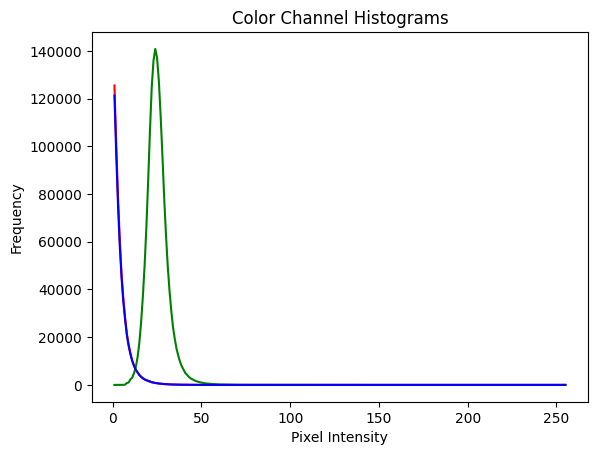

In [5]:
#plot color distributions
colors = ('r', 'g','b')
channel_ids = (0, 1,2)

plt.figure()
plt.title('Color Channel Histograms')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

for channel_id, color in zip(channel_ids, colors):
    histogram, bin_edges = np.histogram(
        frame_rgb[:, :, channel_id], bins=255, range=(1, 256)
    )
    plt.plot(bin_edges[0:-1], histogram, color=color)

plt.show()

## Compute calcium activity

In [29]:
def save_in_h5(h5File,dsetname,data):
    '''
    saves the dataset data under the name dsetname in the h5 file h5File
    '''
    if not dsetname in h5File.keys():
        dset = h5File.create_dataset(dsetname, (np.shape(data)), dtype="f4", compression="gzip")
    else:
        dset = h5File[dsetname]
        
    dset[...] = data

In [30]:
cap = cv2.VideoCapture(video_path)

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
T = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
Activity = np.zeros((4, T))#activity of green channel devided by red channel
ActivityMax = np.zeros((4, T))
ActivityMean = np.zeros((4, T))#activity of green channel
VolumeTrack = np.zeros(T)
time_scale = 0.49548# time difference between consecutive frames
time = time_scale*np.array(range(T))

In [31]:
cap = cv2.VideoCapture(video_path)

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)    
    mask_filename = os.path.join(mask_dir, f'frame_{frame_idx:05d}.png')

    # Check if the mask file exists
    if os.path.exists(mask_filename):
        mask = cv2.imread(mask_filename, cv2.IMREAD_GRAYSCALE) 
        if mask.shape[:2] != frame.shape[:2]:
            mask = cv2.resize(mask, (frame_width, frame_height), interpolation=cv2.INTER_NEAREST)
        cellCoorX, cellCoorY= np.nonzero(mask)
        Volume = len(cellCoorX)
        cellInt = np.zeros((3, Volume))#intensity of each pixel in the mask of cell
        VolumeTrack[frame_idx] = Volume
        for j in range(Volume):
            cellInt[0, j] = frame_rgb[cellCoorX[j], cellCoorY[j], 1]  # red channel intensity
            cellInt[1, j] = frame_rgb[cellCoorX[j],cellCoorY[j], 0]
            cellInt[2, j] = frame_rgb[cellCoorX[j],cellCoorY[j], 2]
        if  Volume > 0:
            ActivityMax[0, frame_idx] = np.max(cellInt[0])  # /MaxFrR
            ActivityMax[1, frame_idx] = np.max(cellInt[1])  # /MaxFrGr
            ActivityMax[3, frame_idx] = np.max(cellInt[2])  # /MaxFrGr
            ActivityMax[2, frame_idx] = ActivityMax[1, frame_idx]/ActivityMax[0, frame_idx]
            # Mean of the whole mask
            ActivityMean[0,frame_idx] = np.mean(cellInt[0])#red
            ActivityMean[1,frame_idx] = np.mean(cellInt[1])/ActivityMean[0,frame_idx]#green/red
            ActivityMean[2,frame_idx] = np.mean(cellInt[1])#green
            ActivityMean[3,frame_idx] = np.mean(cellInt[2])#blue
            # MeanMode
            if Volume > 20:
                TopPix = int(Volume/3) + 3#top 30 percent
                Sort = np.argsort(cellInt[0, :])#sort the red channel activity
                cellIntSorted_R = cellInt[0,Sort]#top in red
                cellIntSorted_g = cellInt[1, Sort]#top in green
                cellIntSorted_B = cellInt[2, Sort]#top in blue
                
                Activity[0, frame_idx] = np.mean(cellIntSorted_R[-TopPix:])#red channel intensity
                Activity[1,frame_idx] = np.mean(cellIntSorted_g[-TopPix:])/Activity[0,frame_idx]
                Activity[2,frame_idx] = np.mean(cellIntSorted_g[-TopPix:])
                Activity[3,frame_idx] = np.mean(cellIntSorted_B[-TopPix:])
            else:
                Activity[:,frame_idx] = ActivityMean[:,frame_idx]
    frame_idx += 1                

### Plot acquired activities

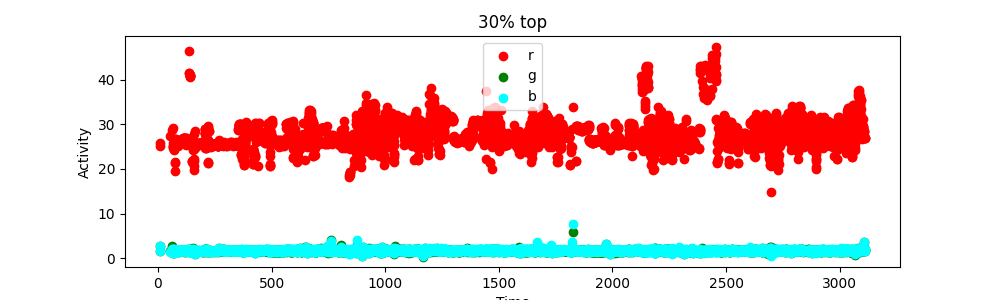

In [32]:
%matplotlib widget
colors = ['r', 'blue', 'g','cyan']  # Red, Green, Blue
lab = ['r','g/r','g','b']

plt.figure(figsize=(10,3))

for i in [0,2,3]:
    nonz = np.nonzero(ActivityMean[i, :])[0]
    plt.scatter(time[nonz], ActivityMean[i, nonz], color=colors[i], label=lab[i])

plt.xlabel('Time')
plt.ylabel('Activity')
plt.title('30% top')
plt.legend()
plt.show()

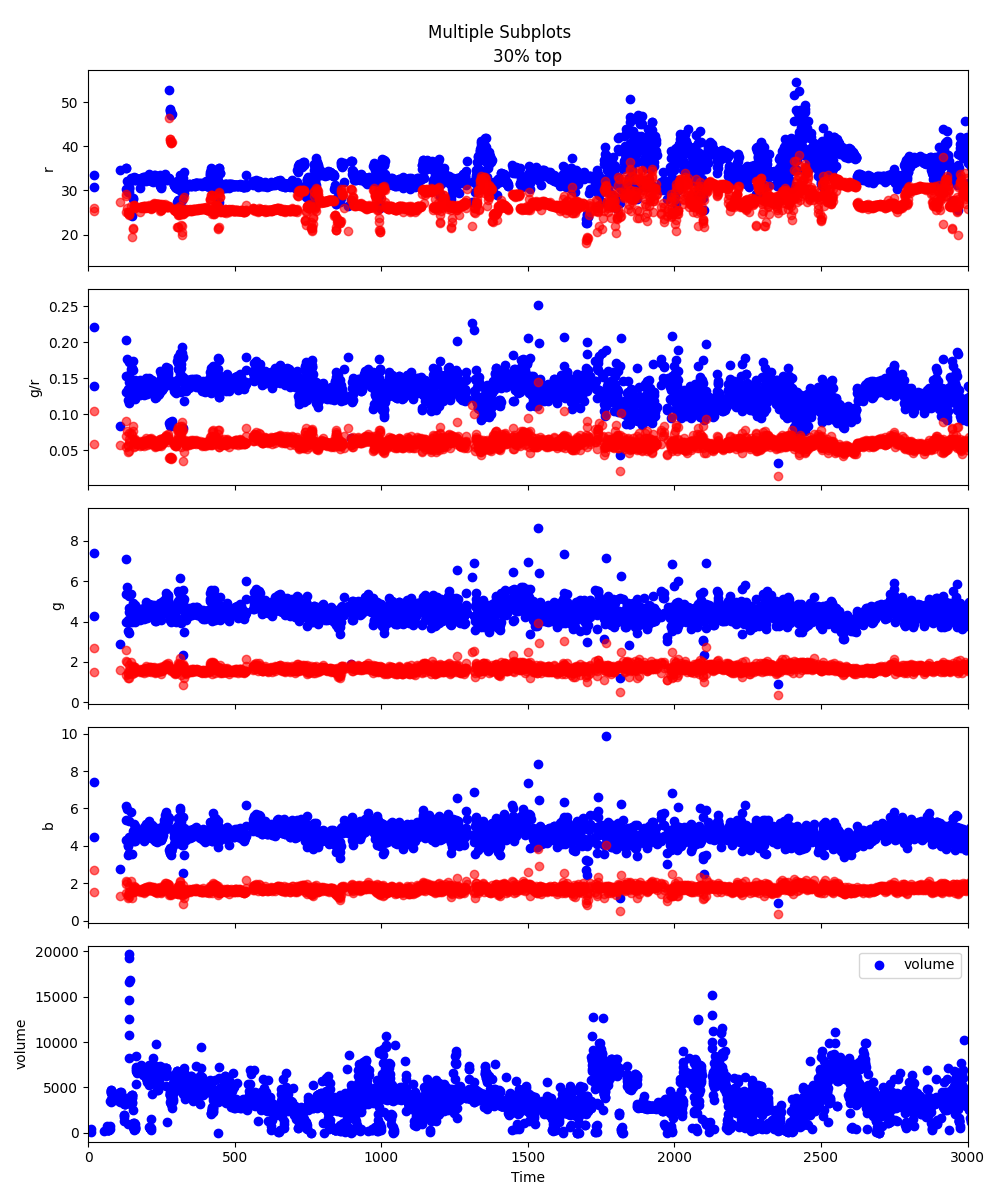

In [33]:
colors = ['r', 'blue', 'g','cyan']  # Red, Green, Blue
lab = ['r','g/r','g','b']
Limit=3000
fig, axs = plt.subplots(5, 1,figsize = (10,12),sharex=True)  # 2x2 grid of subplots
fig.suptitle('Multiple Subplots')

for i in range(4):
    nonz = np.nonzero(Activity[i, :])[0]
    axs[i].scatter(nonz, Activity[i, nonz], color=colors[1], label='30%')
    nonz = np.nonzero(ActivityMean[i, :])[0]
    axs[i].scatter(nonz, ActivityMean[i, nonz], color=colors[0], label='mean',alpha=0.6)
    axs[i].set_ylabel(lab[i])
    axs[i].set_xlim(0,Limit)
nonz = np.nonzero(VolumeTrack)[0]
axs[4].scatter(time[nonz], VolumeTrack[nonz], color=colors[1], label='volume')

axs[4].set_xlabel('Time')
axs[4].set_ylabel('volume')
axs[0].set_title('30% top')
axs[4].set_xlim(0,Limit)
plt.legend()
plt.tight_layout()
plt.show()

### Save activity in h5 file

In [34]:
hdfout = '/mnt/DATA/Mahsa/movies/LongRecordings/2024-09-17/W2tq9262/Activity_20240917_151717red.h5'
name = '2024-09-17RIM'
hf = h5py.File(hdfout, 'w')

In [35]:

hf.attrs["name"]=name
hf.attrs["neuron_Number"]=2

save_in_h5(hf,"Time_series-s",time)
save_in_h5(hf,"Real_time_series",time)
save_in_h5(hf,"Mean_30perc/Red",Activity[0,:])
save_in_h5(hf,"Mean_30perc/Green",Activity[2,:])
save_in_h5(hf,"Mean_30perc/ratio",Activity[1,:])

save_in_h5(hf,"Max/Red",ActivityMax[0,:])
save_in_h5(hf,"Max/ratio",ActivityMax[1,:])
save_in_h5(hf,"Max/Green",ActivityMax[2,:])

save_in_h5(hf,"Mean/Red",ActivityMean[0,:])
save_in_h5(hf,"Mean/Green",ActivityMean[2,:])
save_in_h5(hf,"Mean/ratio",ActivityMean[1,:])
save_in_h5(hf,"Volume tracks",VolumeTrack)

In [37]:
hf.close()